In [5]:
!pip install -q scikit-image joblib tqdm

In [6]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd

from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from scipy.fft import fft2, fftshift

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Triangular_Diffraction_Dataset.zip"

In [55]:
import zipfile
import os

UNZIPPED_PATH = "/content/Triangular_Diffraction_Dataset"


if not os.path.exists(UNZIPPED_PATH):
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall(UNZIPPED_PATH)
    print(f"Dataset unzipped to: {UNZIPPED_PATH}")


DATASET_PATH = UNZIPPED_PATH

folders = sorted(os.listdir(DATASET_PATH))

print("Random Forest related data loading and feature extraction removed.")

Random Forest related data loading and feature extraction removed.


In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [57]:
IMG_SIZE = 64
CHANNELS = 1

X_cnn = []
y_cnn_raw = []

print("Loading and preprocessing images for CNN...")

for folder in tqdm(folders):
    if not folder.startswith("TC_"):
        continue

    tc = int(folder.replace("TC_", ""))
    folder_path = os.path.join(UNZIPPED_PATH, folder)

    for file in os.listdir(folder_path):
        if not file.endswith(".png"):
            continue

        path = os.path.join(folder_path, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img_normalized = img_resized / 255.0

        X_cnn.append(img_normalized)
        y_cnn_raw.append(tc)

X_cnn = np.array(X_cnn)
y_cnn_raw = np.array(y_cnn_raw)


X_cnn = X_cnn.reshape(-1, IMG_SIZE, IMG_SIZE, CHANNELS)

print(f"Original TC values loaded for CNN: {np.unique(y_cnn_raw)}")
print(f"X_cnn shape: {X_cnn.shape}")
print(f"y_cnn_raw shape: {y_cnn_raw.shape}")


label_encoder = LabelEncoder()
y_cnn_encoded = label_encoder.fit_transform(y_cnn_raw)
num_classes = len(label_encoder.classes_)

print(f"Encoded TC labels for CNN: {np.unique(y_cnn_encoded)}")
print(f"Number of classes: {num_classes}")


Loading and preprocessing images for CNN...


100%|██████████| 100/100 [00:43<00:00,  2.31it/s]


Original TC values loaded for CNN: [-50 -49 -48 -47 -46 -45 -44 -43 -42 -41 -40 -39 -38 -37 -36 -35 -34 -33
 -32 -31 -30 -29 -28 -27 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15
 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2  -1   1   2   3   4
   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22
  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40
  41  42  43  44  45  46  47  48  49  50]
X_cnn shape: (3000, 64, 64, 1)
y_cnn_raw shape: (3000,)
Encoded TC labels for CNN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
Number of classes: 100


In [58]:
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_cnn,
    y_cnn_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn_encoded
)

print(f"\nCNN Training data shape: {X_train_cnn.shape}, {y_train_cnn.shape}")
print(f"CNN Validation data shape: {X_val_cnn.shape}, {y_val_cnn.shape}")



CNN Training data shape: (2400, 64, 64, 1), (2400,)
CNN Validation data shape: (600, 64, 64, 1), (600,)


In [59]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 695,524 (2.65 MB)

 Trainable params: 695,524 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
print("\nTraining CNN model...")
history = model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=40,
    batch_size=32,
    validation_data=(X_val_cnn, y_val_cnn),
    verbose=1
)



Training CNN model...
Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 39s 464ms/step - accuracy: 0.0225 - loss: 4.4506 - val_accuracy: 0.0600 - val_loss: 3.9173
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 305ms/step - accuracy: 0.0617 - loss: 3.7227 - val_accuracy: 0.1533 - val_loss: 3.0203
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - accuracy: 0.1033 - loss: 3.1745 - val_accuracy: 0.3000 - val_loss: 2.4470
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - accuracy: 0.1779 - loss: 2.7118 - val_accuracy: 0.4967 - val_loss: 1.8787
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 237ms/step - accuracy: 0.2575 - loss: 2.3045 - val_accuracy: 0.5583 - val_loss: 1.4555
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.3354 - loss: 1.9868 - val_accuracy: 0.6850 - val_loss: 1.1575
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 262ms/step - accuracy: 0.4058 - loss: 1.6996 - val_accuracy: 0.7633 - val_loss: 0.9366
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 229ms/step - accuracy: 0.4625 - 


Evaluating CNN model...
CNN Validation Loss: 0.1755
CNN Validation Accuracy: 0.9667


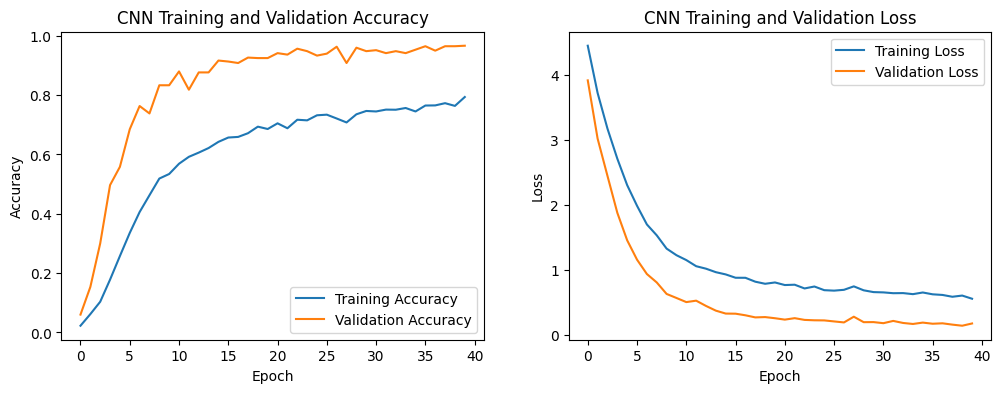

In [61]:
print("\nEvaluating CNN model...")
loss, accuracy = model.evaluate(X_val_cnn, y_val_cnn, verbose=0)
print(f"CNN Validation Loss: {loss:.4f}")
print(f"CNN Validation Accuracy: {accuracy:.4f}")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step

CNN Classification Report:
              precision    recall  f1-score   support

         -50       1.00      1.00      1.00         6
         -49       1.00      1.00      1.00         6
         -48       1.00      1.00      1.00         6
         -47       1.00      0.67      0.80         6
         -46       1.00      1.00      1.00         6
         -45       1.00      0.83      0.91         6
         -44       0.75      1.00      0.86         6
         -43       1.00      1.00      1.00         6
         -42       0.86      1.00      0.92         6
         -41       1.00      1.00      1.00         6
         -40       1.00      0.83      0.91         6
         -39       1.00      1.00      1.00         6
         -38       0.83      0.83      0.83         6
         -37       0.86      1.00      0.92         6
         -36       0.86      1.00      0.92         6
         -35       0.83      0.83      0.83         6
         -34

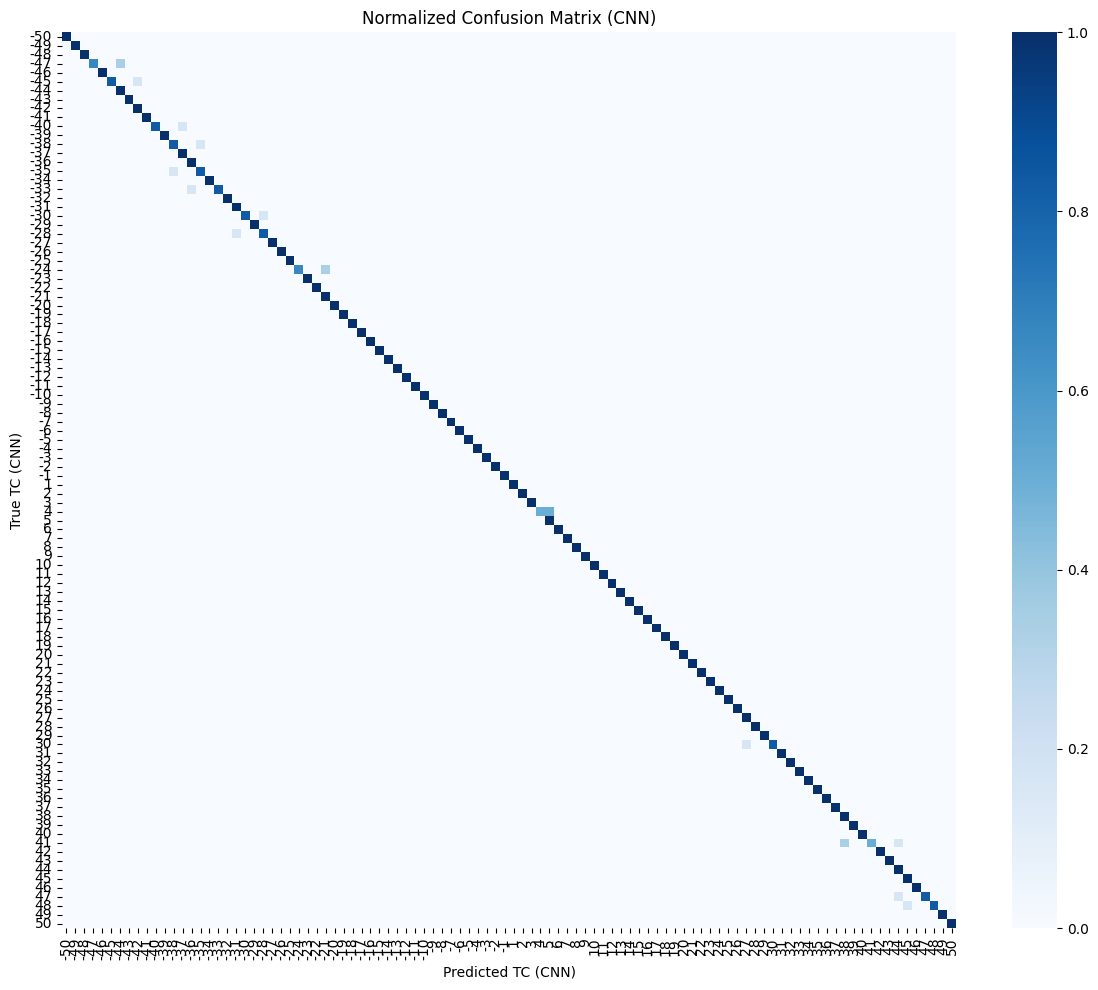

In [62]:
cnn_pred_probs = model.predict(X_val_cnn)
cnn_pred_labels = np.argmax(cnn_pred_probs, axis=1)

print("\nCNN Classification Report:")
print(classification_report(y_val_cnn, cnn_pred_labels, target_names=label_encoder.classes_.astype(str)))

cm_cnn = confusion_matrix(y_val_cnn, cnn_pred_labels)
cm_cnn = cm_cnn.astype('float') / cm_cnn.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_cnn, annot=False, cmap='Blues', fmt=".2f",
            xticklabels=label_encoder.classes_.astype(str),
            yticklabels=label_encoder.classes_.astype(str))
plt.xlabel("Predicted TC (CNN)")
plt.ylabel("True TC (CNN)")
plt.title("Normalized Confusion Matrix (CNN)")
plt.tight_layout()
plt.show()


In [63]:
image_path = "/content/Triangular_Diffraction_Dataset/TC_-20/TC_-20_12.png"

img = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)


if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_normalized = img_resized / 255.0


    img_cnn_input = img_normalized.reshape(1, IMG_SIZE, IMG_SIZE, CHANNELS)

    cnn_pred_probs = model.predict(img_cnn_input)
    cnn_pred_label_encoded = np.argmax(cnn_pred_probs, axis=1)[0]

    prediction = label_encoder.inverse_transform([cnn_pred_label_encoded])[0]

    print(f"Predicted TC = {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Predicted TC = -20


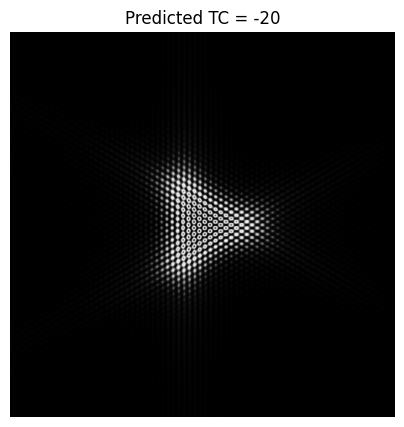

In [64]:
import matplotlib.pyplot as plt

if img is not None:
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted TC = {prediction}")
    plt.axis('off')
    plt.show()
else:
    print("Cannot display image as it was not loaded.")